In [1]:
import pandas as pd

In [9]:
df = pd.read_csv('ETH_1h.csv')

In [10]:
df.head()

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 08-PM,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 07-PM,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,2020-03-13 06-PM,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 05-PM,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 04-PM,ETHUSD,124.85,129.51,120.17,124.08,4461424.71


In [11]:
df.shape

(23674, 7)

In [12]:
df.iloc[0]

Date      2020-03-13 08-PM
Symbol              ETHUSD
Open                129.94
High                131.82
Low                 126.87
Close               128.71
Volume         1.94067e+06
Name: 0, dtype: object

In [13]:
df.loc[0,'Date']

'2020-03-13 08-PM'

In [ ]:
df['Date'].dtype 
#In Pandas, dtype('O') is the most common way text data (strings) is stored.
#dtype('O') means we expect the strings 

dtype('O')

In [15]:
df.loc[0,'Date'].day_name

AttributeError: 'str' object has no attribute 'day_name'

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

ParserError: Unknown string format: 2020-03-13 08-PM

In [16]:
df['Date'] = pd.to_datetime(df['Date'],format='%Y-%m-%d %I-%p') #pd.to_datetime converts a argument to datetime. The format argument specifies the expected format of the input string.
#'2020-03-13 08-PM'


In [ ]:
df['Date']


0       2020-03-13 20:00:00
1       2020-03-13 19:00:00
2       2020-03-13 18:00:00
3       2020-03-13 17:00:00
4       2020-03-13 16:00:00
                ...        
23669   2017-07-01 15:00:00
23670   2017-07-01 14:00:00
23671   2017-07-01 13:00:00
23672   2017-07-01 12:00:00
23673   2017-07-01 11:00:00
Name: Date, Length: 23674, dtype: datetime64[ns]

In [19]:
df['Date'].dtype

dtype('<M8[ns]')

In [ ]:
df.loc[0,'Date'].day_name()


'Friday'

In [22]:

#lambda arguments: expression , 

# lambda syntax is used to create anonymous functions in Python. 

# It allows you to define a function without giving it a name. 
# The arguments are the input parameters for the function, 
# and the expression is the output that the function will return.   

#add = lambda x, y: x + y
#print(add(3, 4))  # Output: 7

#check_even = lambda x: "Even" if x % 2 == 0 else "Odd"
#print(check_even(10))  # Output: Even

d_parser = lambda x: pd.datetime.strptime(x, '%Y-%m-%d %I-%p')
df1 = pd.read_csv('ETH_1h.csv',parse_dates=['Date'],date_parser=d_parser)

<ipython-input-22-134bc6887241>:15: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  d_parser = lambda x: pd.datetime.strptime(x, '%Y-%m-%d %I-%p')


In [23]:
df1.head()

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71


In [24]:
df1['Date'].dt.day_name()

0          Friday
1          Friday
2          Friday
3          Friday
4          Friday
           ...   
23669    Saturday
23670    Saturday
23671    Saturday
23672    Saturday
23673    Saturday
Name: Date, Length: 23674, dtype: object

In [25]:
df1['DayofWeek'] = df1['Date'].dt.day_name()


In [26]:
df1.head()

,Date,Symbol,Open,High,Low,Close,Volume,DayofWeek
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2,2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,Friday
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday


In [27]:
df1['Date'].min()

Timestamp('2017-07-01 11:00:00')

In [28]:
df1['Date'].max()

Timestamp('2020-03-13 20:00:00')

In [29]:
time_delta  =df1['Date'].max()-df1['Date'].min()

In [ ]:
time_delta

Timedelta('986 days 09:00:00')

In [30]:
filt = (df1['Date'] >= '2020')
df1.loc[filt]

,Date,Symbol,Open,High,Low,Close,Volume,DayofWeek
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2,2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,Friday
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday
...,...,...,...,...,...,...,...,...
1744,2020-01-01 04:00:00,ETHUSD,129.57,130.00,129.50,129.56,702786.82,Wednesday
1745,2020-01-01 03:00:00,ETHUSD,130.37,130.44,129.38,129.57,496704.23,Wednesday
1746,2020-01-01 02:00:00,ETHUSD,130.14,130.50,129.91,130.37,396315.72,Wednesday
1747,2020-01-01 01:00:00,ETHUSD,128.34,130.14,128.32,130.14,635419.40,Wednesday


In [31]:
filt1 = ((df1['Date'] >= '2019') & (df1['Date'] < '2020'))
df1.loc[filt1]

,Date,Symbol,Open,High,Low,Close,Volume,DayofWeek
1749,2019-12-31 23:00:00,ETHUSD,128.33,128.69,128.14,128.54,440678.91,Tuesday
1750,2019-12-31 22:00:00,ETHUSD,128.38,128.69,127.95,128.33,554646.02,Tuesday
1751,2019-12-31 21:00:00,ETHUSD,127.86,128.43,127.72,128.38,350155.69,Tuesday
1752,2019-12-31 20:00:00,ETHUSD,127.84,128.34,127.71,127.86,428183.38,Tuesday
1753,2019-12-31 19:00:00,ETHUSD,128.69,128.69,127.60,127.84,1169847.84,Tuesday
...,...,...,...,...,...,...,...,...
10504,2019-01-01 04:00:00,ETHUSD,130.75,133.96,130.74,131.96,2791135.37,Tuesday
10505,2019-01-01 03:00:00,ETHUSD,130.06,130.79,130.06,130.75,503732.63,Tuesday
10506,2019-01-01 02:00:00,ETHUSD,130.79,130.88,129.55,130.06,838183.43,Tuesday
10507,2019-01-01 01:00:00,ETHUSD,131.62,131.62,130.77,130.79,434917.99,Tuesday


In [32]:
filt1 = ((df1['Date'] >= pd.to_datetime('2019-01-01')) & (df1['Date'] < pd.to_datetime('2020-02-01')))
df1.loc[filt1]

,Date,Symbol,Open,High,Low,Close,Volume,DayofWeek
1005,2020-01-31 23:00:00,ETHUSD,181.73,181.73,179.00,179.74,438575.26,Friday
1006,2020-01-31 22:00:00,ETHUSD,180.66,182.24,180.03,181.73,754254.39,Friday
1007,2020-01-31 21:00:00,ETHUSD,180.31,181.04,179.98,180.66,657922.36,Friday
1008,2020-01-31 20:00:00,ETHUSD,179.19,180.51,179.13,180.31,979846.20,Friday
1009,2020-01-31 19:00:00,ETHUSD,179.10,179.57,178.71,179.19,353169.87,Friday
...,...,...,...,...,...,...,...,...
10504,2019-01-01 04:00:00,ETHUSD,130.75,133.96,130.74,131.96,2791135.37,Tuesday
10505,2019-01-01 03:00:00,ETHUSD,130.06,130.79,130.06,130.75,503732.63,Tuesday
10506,2019-01-01 02:00:00,ETHUSD,130.79,130.88,129.55,130.06,838183.43,Tuesday
10507,2019-01-01 01:00:00,ETHUSD,131.62,131.62,130.77,130.79,434917.99,Tuesday


In [33]:
df1.set_index('Date',inplace=True)
df1

,Symbol,Open,High,Low,Close,Volume,DayofWeek
Date,,,,,,,
2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2020-03-13 18:00:00,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,Friday
2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday
...,...,...,...,...,...,...,...
2017-07-01 15:00:00,ETHUSD,265.74,272.74,265.00,272.57,1500282.55,Saturday
2017-07-01 14:00:00,ETHUSD,268.79,269.90,265.00,265.74,1702536.85,Saturday
2017-07-01 13:00:00,ETHUSD,274.83,274.93,265.00,268.79,3010787.99,Saturday


In [40]:
df1.loc['2019']


,Symbol,Open,High,Low,Close,Volume,DayofWeek
Date,,,,,,,
2019-12-31 23:00:00,ETHUSD,128.33,128.69,128.14,128.54,440678.91,Tuesday
2019-12-31 22:00:00,ETHUSD,128.38,128.69,127.95,128.33,554646.02,Tuesday
2019-12-31 21:00:00,ETHUSD,127.86,128.43,127.72,128.38,350155.69,Tuesday
2019-12-31 20:00:00,ETHUSD,127.84,128.34,127.71,127.86,428183.38,Tuesday
2019-12-31 19:00:00,ETHUSD,128.69,128.69,127.60,127.84,1169847.84,Tuesday
...,...,...,...,...,...,...,...
2019-01-01 04:00:00,ETHUSD,130.75,133.96,130.74,131.96,2791135.37,Tuesday
2019-01-01 03:00:00,ETHUSD,130.06,130.79,130.06,130.75,503732.63,Tuesday
2019-01-01 02:00:00,ETHUSD,130.79,130.88,129.55,130.06,838183.43,Tuesday


In [43]:
df1.loc['2020-01':'2020-02']['Close'].mean()

195.16559027777814

In [50]:
highs = df1['High'].resample('D').max()


In [49]:
%matplotlib inline


<AxesSubplot:xlabel='Date'>

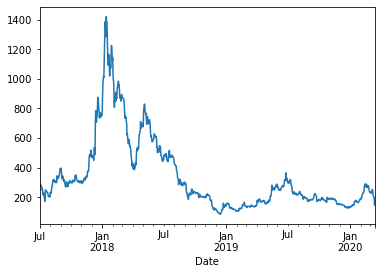

In [53]:
highs.plot()

<AxesSubplot:xlabel='Date'>

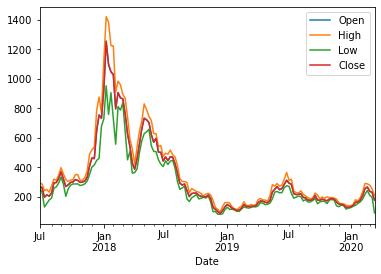

In [55]:
df1.resample('W').agg({'Open':'mean','High':'max','Low':'min','Close':'mean'}).plot()